In [1]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from collections import defaultdict
from tqdm import tqdm
import itertools

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from anndata import AnnData, concat
import scanpy as sc


/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: 

In [2]:
# First run this cell
!gunzip data/mouse_vdjdb_extracted_features_df.csv.gz

In [3]:
_mouse_df = pd.read_csv('data/mouse_vdjdb_extracted_features_df.csv',index_col=0)
mouse_df = _mouse_df[_mouse_df['label'].isin(['positive','permuted_negative'])].drop(columns=['A_seq', 'B_seq','M_seq','P_seq'])

In [4]:
mouse_avg_df = mouse_df.groupby(by=["original_index","label"],dropna=False).mean().drop(columns=['af3_seed', 'af3_sample', 'af3_ranking']).reset_index()
mouse_std_df = mouse_df.groupby(by=["original_index","label"],dropna=False).std().drop(columns=['af3_seed', 'af3_sample', 'af3_ranking']).reset_index()

mouse_features_df = mouse_avg_df.join(mouse_std_df,rsuffix='_std').drop(columns=['original_index','label_std','original_index_std'])

In [5]:
mouse_values_df = mouse_features_df.drop(columns=['label'])

In [6]:
def get_classifier(): 
    return LogisticRegression(random_state=16,solver='newton-cholesky')
mouse_features_df['class'] = (mouse_features_df['label']=='positive').astype(int)
_feature_columns = [x for x in mouse_features_df if x not in ['class','label']]
X = mouse_features_df[_feature_columns]
y = mouse_features_df.label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
model = get_classifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba,pos_label='positive')
auc = metrics.roc_auc_score(y_test, y_pred_proba)
model_fi = permutation_importance(model, X, y)

In [7]:
# min max normalization
_X = model_fi['importances_mean']
mouse_importances =  (_X - _X.min(axis=0)) / (_X.max(axis=0) - _X.min(axis=0))

In [8]:
mouse_adata_transpose = AnnData(mouse_features_df[_feature_columns]).transpose()

/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [9]:
mouse_adata_transpose.var['index'] = mouse_adata_transpose.var.index
mouse_adata_transpose.var['label'] = mouse_adata_transpose.var['index'].apply(lambda idx: _mouse_df.loc[int(idx)]['label'])

In [10]:
def get_feature_type(row):
    if 'pae_interaction' in row:
        return 'iPAE'
    if 'pae' in row:
        return 'PAE'
    if 'plddt' in row:
        return 'pLDDT'
    if 'iptm' in row:
        return 'ipTM'
    if 'ptm' in row:
        return 'pTM'
    if 'probs' in row:
        return 'Contact Probs'


def get_granularity(row):
    seps = row.split("_")
    chains = ['A','B','M','P','CDR3a','CDR3b']
    count = 0
    for c in chains:
        if c in seps:
            count += 1
    if count == 0:
        return 'Global Metric'
    if count == 1:
        return 'Per Chain Metric'
    if count == 2:
        return 'Inter-Chain Metric'

def get_chain(row):
    seps = row.split("_")
    chains = ['A','B','M','P','cdr3a','cdr3b']
    chains_found = []
    for c in chains:
        if c in seps:
            chains_found.append(c)
    if len(chains_found) == 0:
        return 'Structure Wide Metric'
    if len(chains_found) == 1:
        return chains_found[0]
    else:
        return "-".join(chains_found)

def get_gross_chain(row):
    seps = row.split("_")
    chains = ['A','B','M','P','cdr3a','cdr3b']
    t_chains = ['A','B','cdr3a','cdr3b']
    pmhc_chains = ['M','P']
    chains_found = []
    for c in chains:
        if c in seps:
            chains_found.append(c)
    if len(chains_found) == 0:
        return 'Global Metric'
    if len(chains_found) == 1:
        chain = chains_found[0]
        if chain in t_chains:
            return 'TCR'
        else:
            return 'pMHC'
    else:
        [chain1, chain2] = chains_found
        if chain1 in t_chains:
            if chain2 in t_chains:
                return 'TCR'
            else:
                return 'TCR-pMHC Interface'
        else:
            if chain2 in t_chains:
                return 'TCR-pMHC Interface'
            else:
                return 'pMHC'

def get_aggregator(row):
    row = row.removesuffix('_std')
    if 'std' in row: return 'std'
    if 'avg' in row: return 'mean'
    if 'min' in row: return 'min'
    if 'max' in row: return 'max'
    return 'ptm'

def get_cross_structure_agg(row):
    return 'std' if row.split('_')[-1]=='std' else 'average'
        
mouse_adata_transpose.obs['name'] = mouse_adata_transpose.obs.index
mouse_adata_transpose.obs['feature_type'] = mouse_adata_transpose.obs.name.apply(get_feature_type)
mouse_adata_transpose.obs['metric_level'] = mouse_adata_transpose.obs.name.apply(get_granularity)
mouse_adata_transpose.obs['chain'] = mouse_adata_transpose.obs.name.apply(get_chain)

mouse_adata_transpose.obs['gross_chain'] = mouse_adata_transpose.obs.name.apply(get_gross_chain)
mouse_adata_transpose.obs['agg'] = mouse_adata_transpose.obs.name.apply(get_aggregator)
mouse_adata_transpose.obs['cross_structure_agg'] = mouse_adata_transpose.obs.name.apply(get_cross_structure_agg)


mouse_adata_transpose.obs['importance'] = mouse_importances

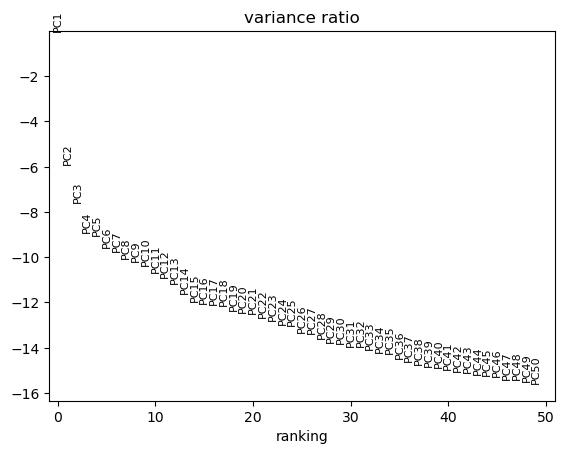

In [11]:
sc.pp.scale(mouse_adata_transpose)
sc.pp.pca(mouse_adata_transpose)
sc.pl.pca_variance_ratio(mouse_adata_transpose, n_pcs=50, log=True)

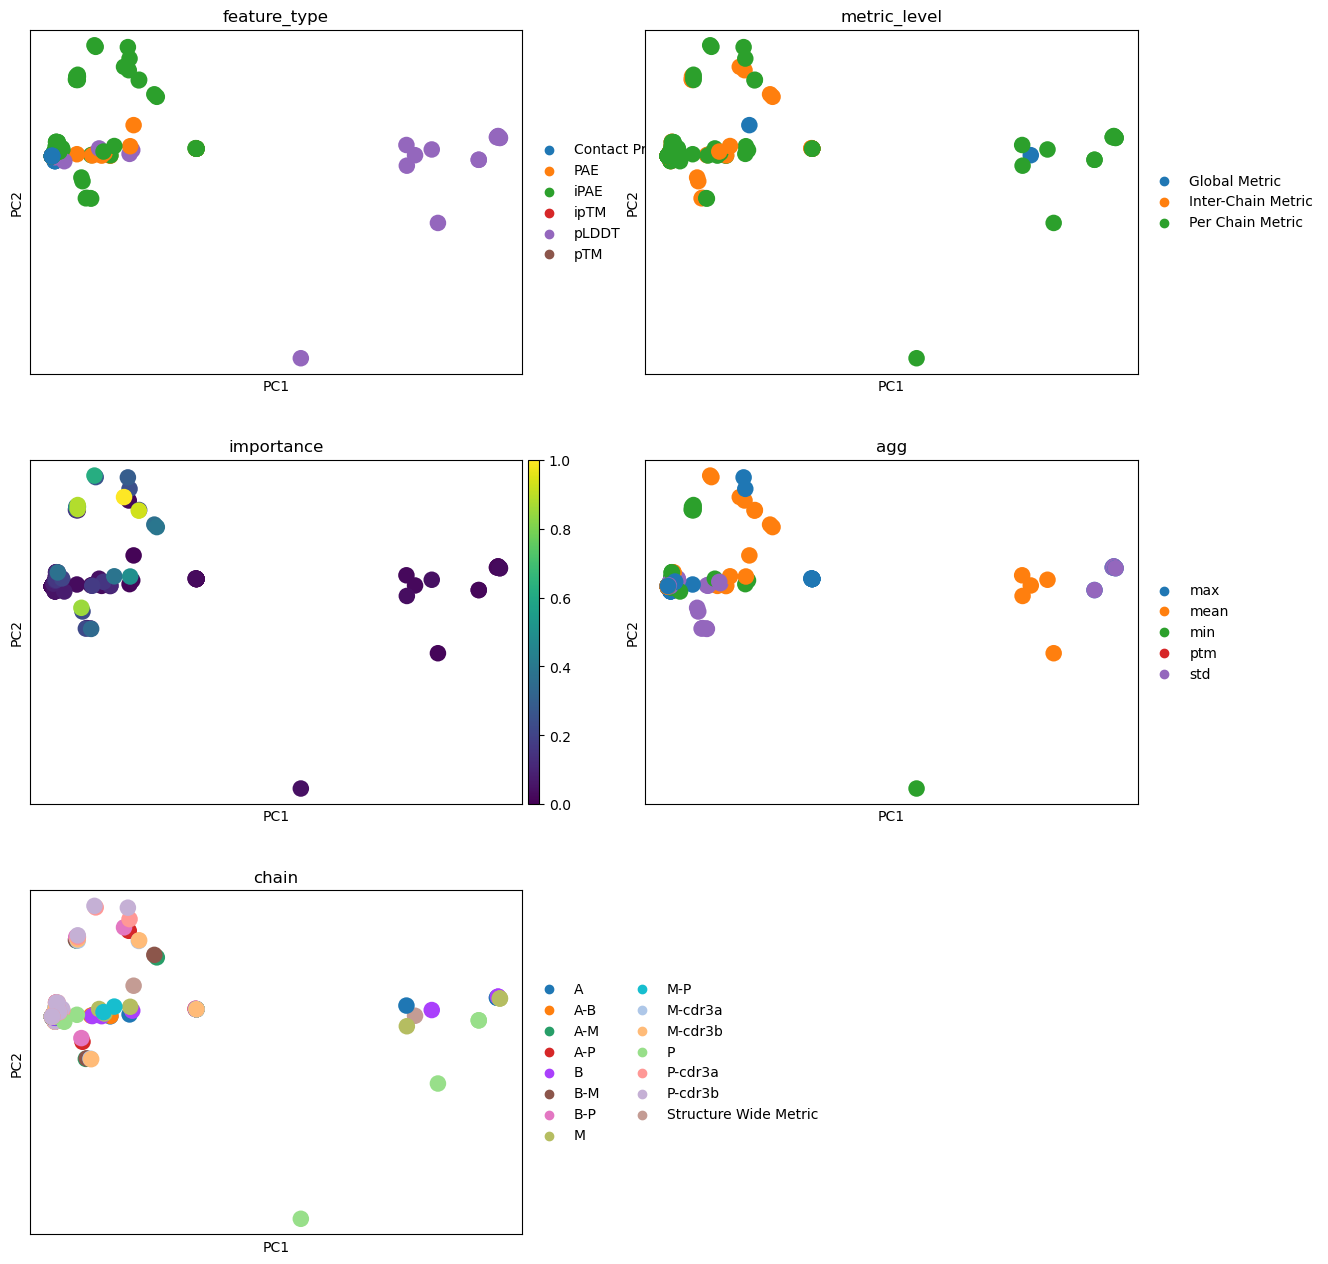

In [12]:
sc.pl.pca(
    mouse_adata_transpose,
    color=["feature_type","metric_level","importance","agg","chain"],
    ncols=2,
)

In [13]:
sc.pp.neighbors(mouse_adata_transpose)
sc.tl.leiden(mouse_adata_transpose,resolution=0.2)
sc.tl.umap(mouse_adata_transpose)

/home/levinej4/miniconda3/envs/aire/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3277420/547139051.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mouse_adata_transpose,resolution=0.2)


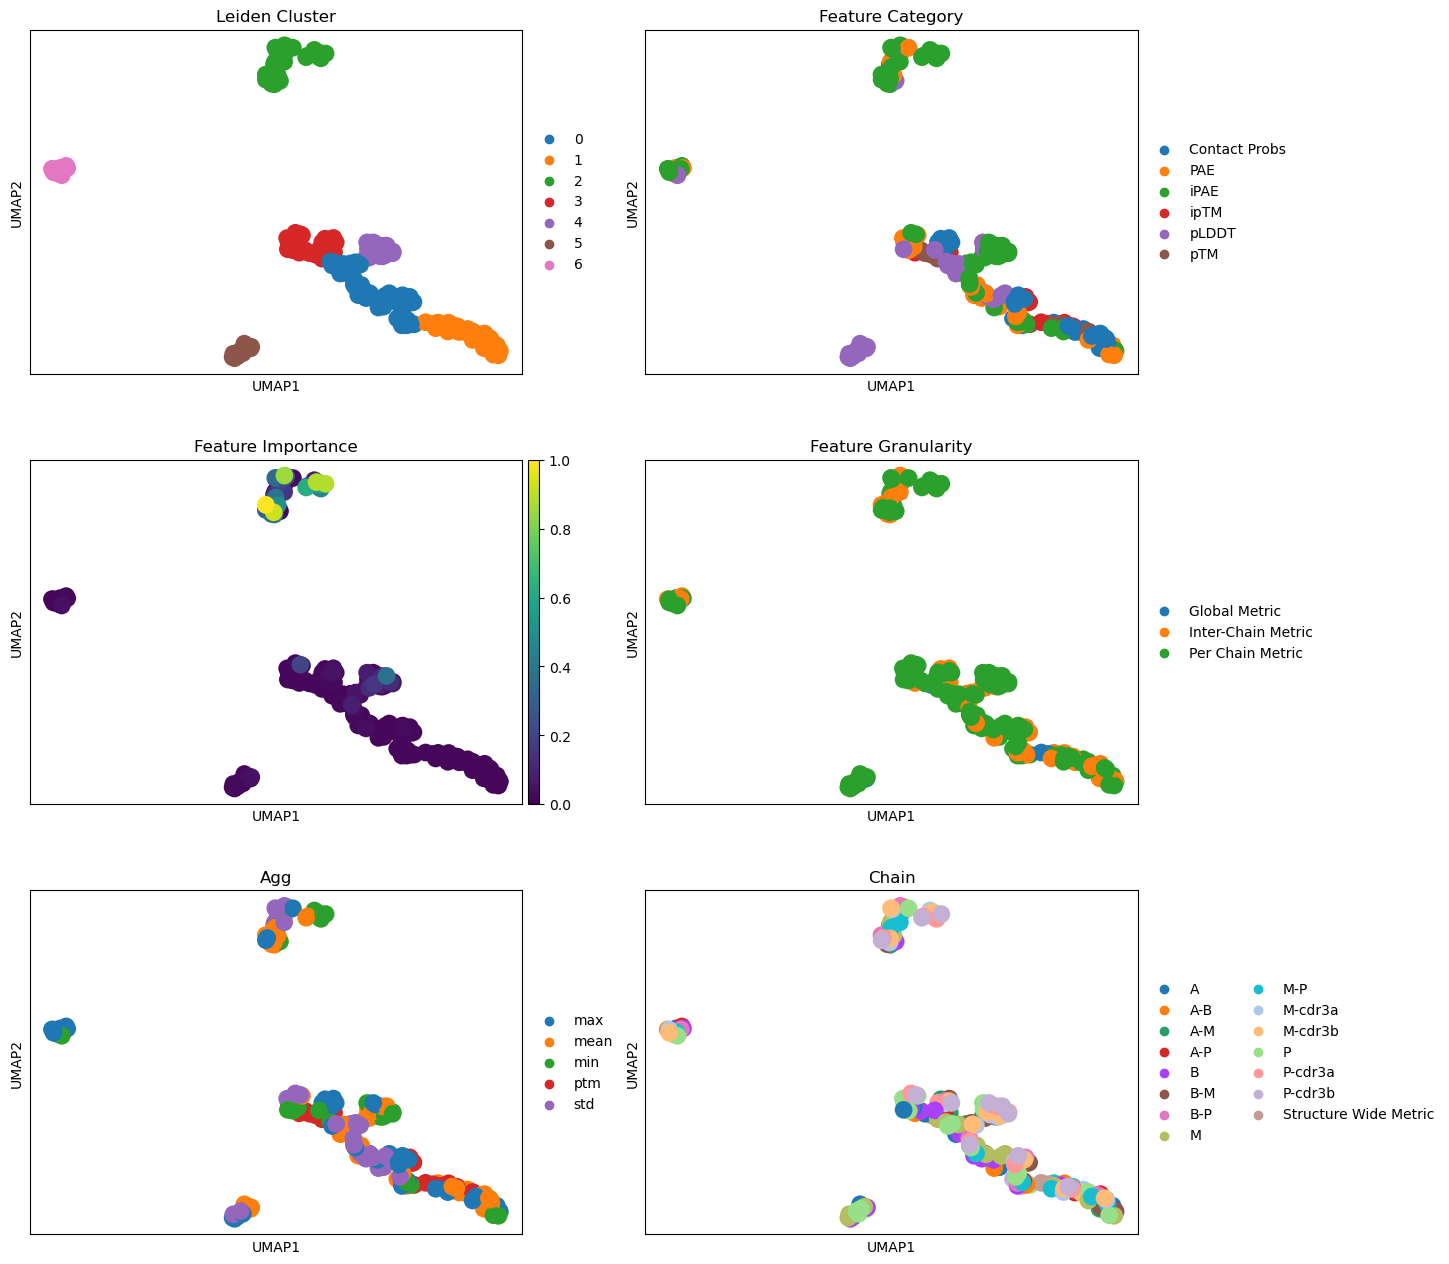

In [14]:
sc.pl.umap(
    mouse_adata_transpose,
    color=["leiden","feature_type", "importance","metric_level","agg","chain"],
    frameon=True,
    ncols=2,
    size=650,
    title=['Leiden Cluster', 'Feature Category','Feature Importance','Feature Granularity', 'Agg','Chain']
)

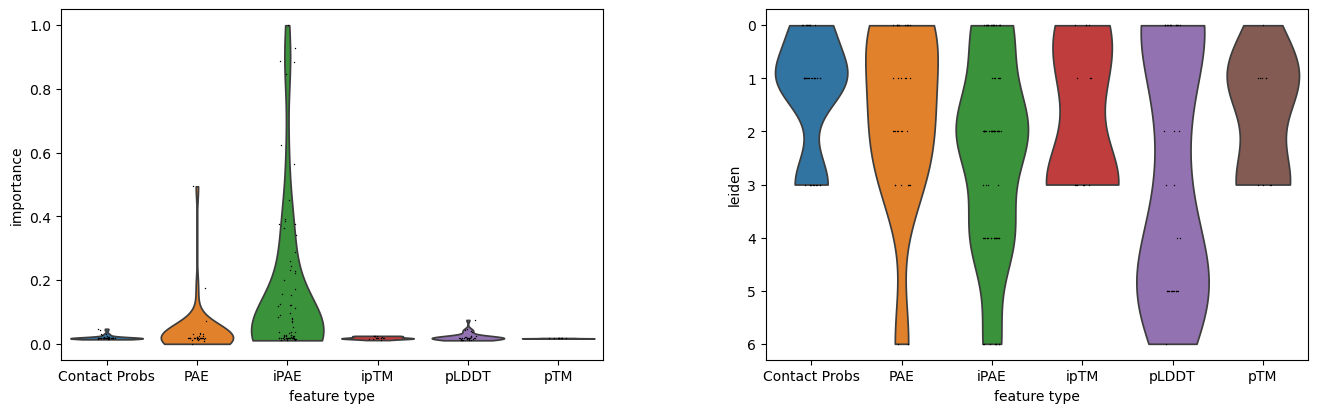

In [15]:
sc.pl.violin(mouse_adata_transpose,groupby='feature_type',keys=['importance','leiden'])